## Cài đặt các thư viện nếu cần

In [1]:
pip install pandas numpy scikit-learn matplotlib

  Using cached pandas-3.0.1-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.3-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.1.1-cp312-cp312-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-3.0.1-cp312-cp312-win_amd64.whl (9.7 MB)
Using cached numpy-2.4.3-cp312-cp312-win_amd64.whl (12.3 MB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.0 MB 2.3 MB/s eta 0:00:04
   ------ -------------


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Import thư viện và đọc dataset

In [2]:
import pandas as pd
import numpy as np

# Load the dataset
data = pd.read_csv('Housing.csv')
print("Shape:", data.shape)
## Data overview
data.head()

Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## Kiểm tra dataset có bị thiếu hay trùng lặp dữ liệu không nếu số lượng không đáng kể sẽ loại bỏ đi để không ảnh hướng tới kết quả 

In [ ]:
# Check for null and duplicate values
import pandas as pd
from IPython.display import display
print(data.info())
print(data.describe())
missing_table = pd.DataFrame(data.isnull().sum())
missing_table.columns = ["Missing Values"]
display(missing_table)
print("Duplicate values:\n", data.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mea

,Missing Values
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


Duplicate values:
 0


## Kiểm tra kiểu dữ liệu của các đặc trưng

In [138]:
dtype_table = data.dtypes.to_frame(name="Data Type")
display(dtype_table)

,Data Type
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,object
guestroom,object
basement,object
hotwaterheating,object
airconditioning,object


Để đồng bộ hóa dataset ta sẽ chuyển các giá trị yes/no | True/Fasle thành 1/0

In [139]:
# Convert 'yes'/'no' to 1/0
binary_columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

for col in binary_columns:
    data[col] = data[col].map({'yes': 1, 'no': 0})
data = pd.get_dummies(data, columns=["furnishingstatus"], drop_first=True)
# Convert 'True'/'False' to 1/0
data['furnishingstatus_semi-furnished'] = data['furnishingstatus_semi-furnished'].astype(int)
data['furnishingstatus_unfurnished'] = data['furnishingstatus_unfurnished'].astype(int)
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


## Xử lý outliers 

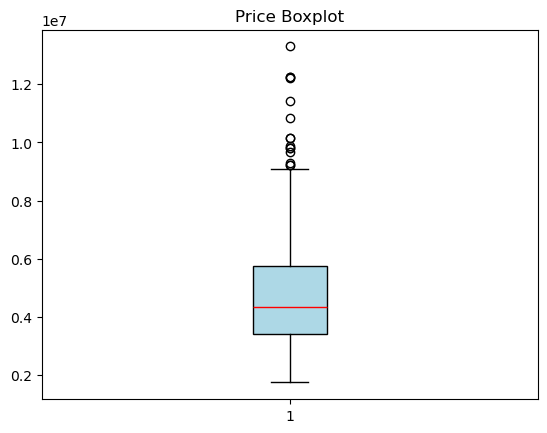

In [140]:
import matplotlib.pyplot as plt
plt.boxplot(
    data["price"],
    patch_artist=True,
    boxprops=dict(facecolor="lightblue"),
    medianprops=dict(color="red"),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black")
)
plt.title("Price Boxplot")
plt.show()

## PHÂN TÍCH DỮ LIỆU

# Thông tin cơ bản về dataset sau khi tiền xử lý

In [141]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   mainroad                         545 non-null    int64
 6   guestroom                        545 non-null    int64
 7   basement                         545 non-null    int64
 8   hotwaterheating                  545 non-null    int64
 9   airconditioning                  545 non-null    int64
 10  parking                          545 non-null    int64
 11  prefarea                         545 non-null    int64
 12  furnishingstatus_semi-furnished  545 non-null    i

# Biểu đồ price distribution

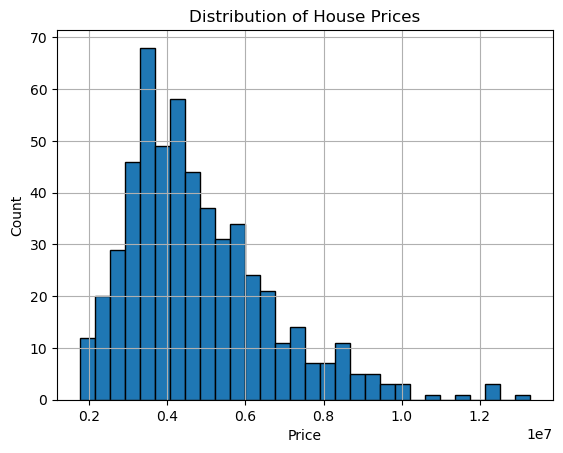

In [142]:
price = data["price"]
plt.figure()

# histogram
plt.hist(price, bins=30, edgecolor="black")

# tiêu đề + label
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")

# grid cho đẹp
plt.grid(True)

plt.show()

# Ma trận tương quan giữa các biến

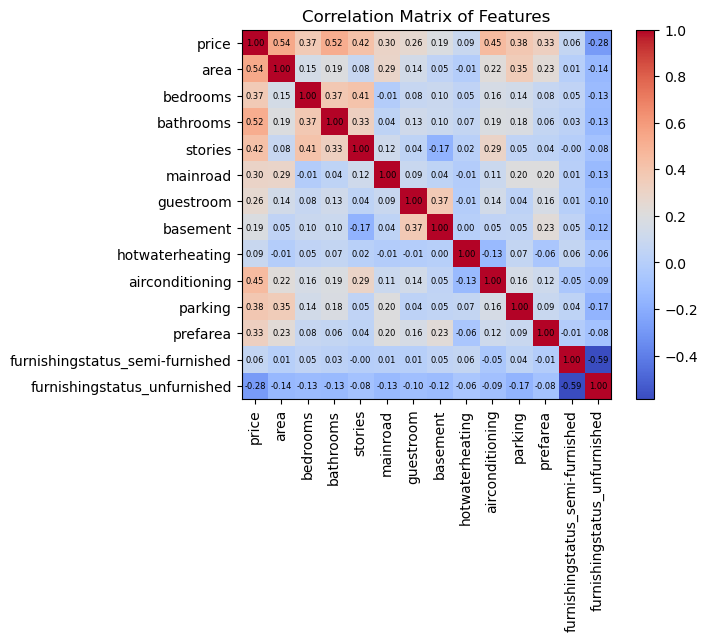

In [143]:
corr_matrix = data.corr()

corr_matrix
plt.figure()

plt.imshow(corr_matrix, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center", fontsize=6)

plt.title("Correlation Matrix of Features")
plt.grid(False)

plt.show()

Biến "area"

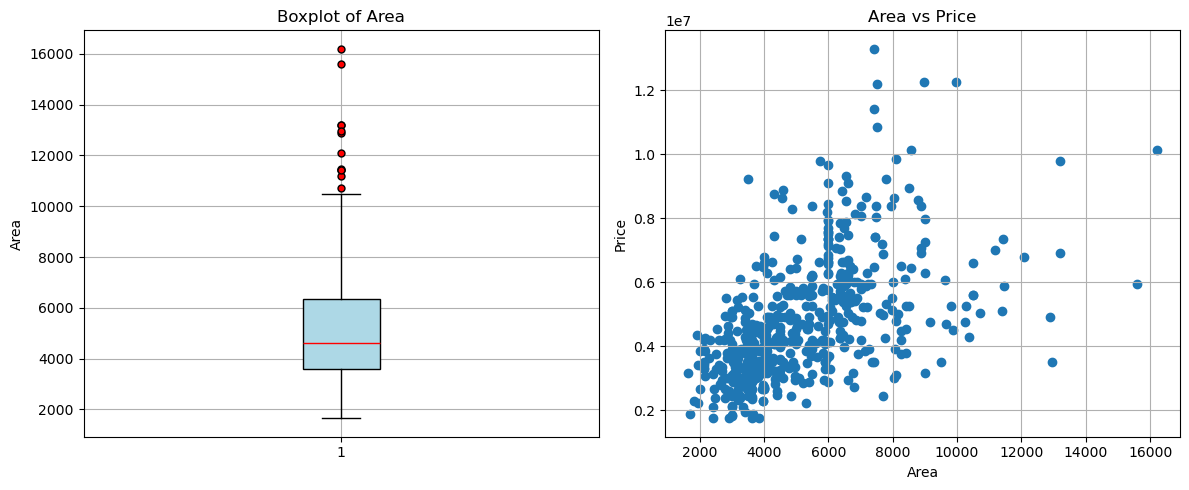

In [144]:
plt.figure(figsize=(12,5))

# 🔹 Biểu đồ 1: Boxplot của area
plt.subplot(1, 2, 1)
plt.boxplot(
    data["area"],
    patch_artist=True,
    boxprops=dict(facecolor="lightblue"),
    medianprops=dict(color="red"),
    flierprops=dict(marker='o', markerfacecolor='red', markersize=5)
)
plt.title("Boxplot of Area")
plt.ylabel("Area")
plt.grid(True)

# 🔹 Biểu đồ 2: Scatter area vs price
plt.subplot(1, 2, 2)
plt.scatter(data["area"], data["price"])
plt.title("Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.grid(True)

plt.tight_layout()
plt.show()

Biến "bedrooms"

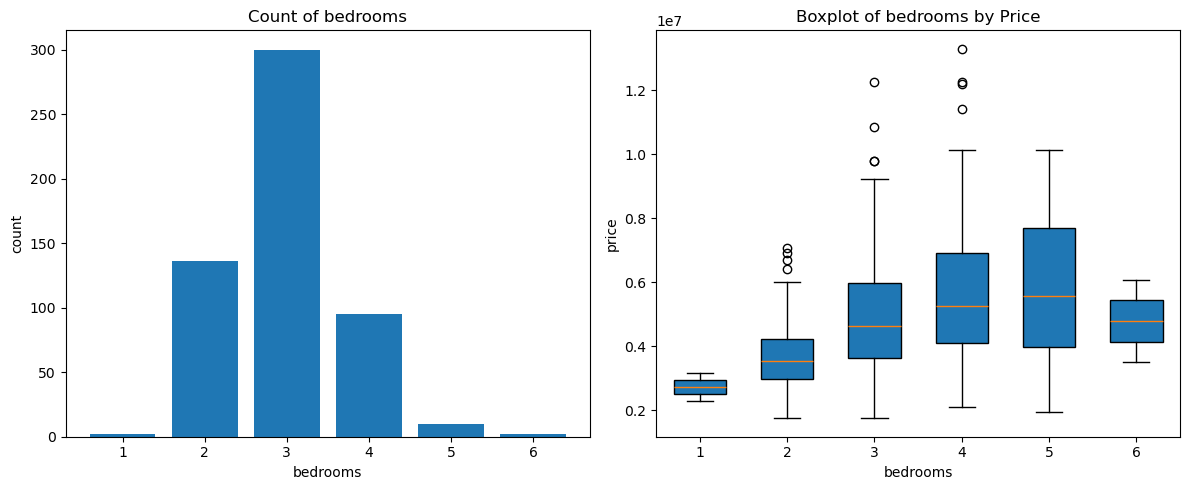

In [145]:
plt.figure(figsize=(12,5))

# 🔹 Biểu đồ 1: Count of bedrooms
plt.subplot(1, 2, 1)

bedroom_counts = data["bedrooms"].value_counts().sort_index()

plt.bar(bedroom_counts.index, bedroom_counts.values)

plt.title("Count of bedrooms")
plt.xlabel("bedrooms")
plt.ylabel("count")

# 🔹 Biểu đồ 2: Boxplot bedrooms theo price
plt.subplot(1,2,2)
labels = sorted(data["bedrooms"].unique())
groups = [data[data["bedrooms"]==b]["price"] for b in labels]

plt.boxplot(groups, patch_artist=True, widths=0.6)
plt.title("Boxplot of bedrooms by Price")
plt.xlabel("bedrooms")
plt.ylabel("price")
plt.xticks(range(1,len(labels)+1), labels)

plt.tight_layout()
plt.show()

Biến "Bathrooms"

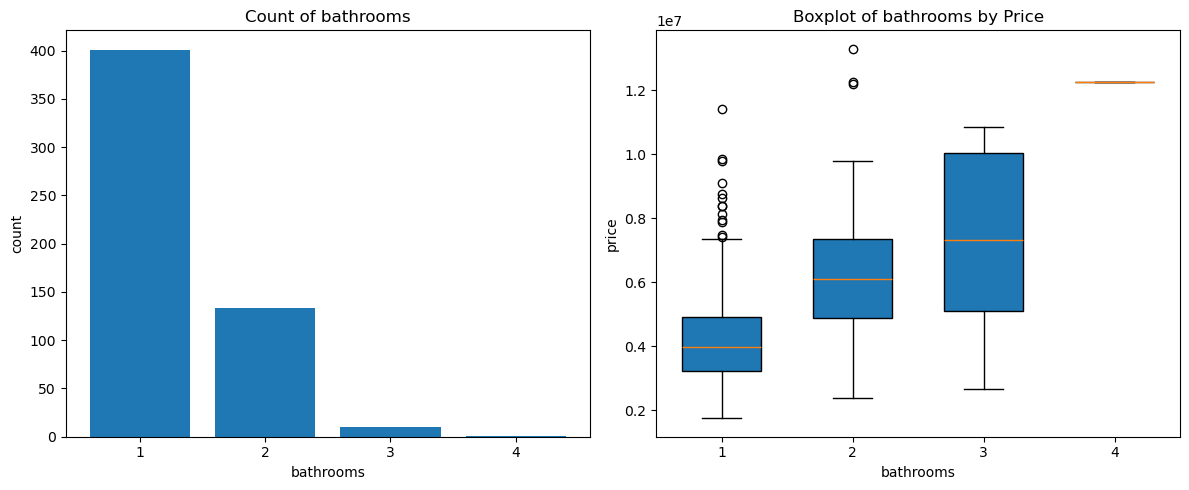

In [146]:
plt.figure(figsize=(12,5))

# 🔹 Biểu đồ 1: Count of bathrooms
plt.subplot(1, 2, 1)

bathroom_count = data["bathrooms"].value_counts().sort_index()

plt.bar(bathroom_count.index, bathroom_count.values)
plt.xticks(bathroom_count.index)
plt.title("Count of bathrooms")
plt.xlabel("bathrooms")
plt.ylabel("count")

# 🔹 Biểu đồ 2: Boxplot bathrooms theo price
plt.subplot(1,2,2)
labels = sorted(data["bathrooms"].unique())
groups = [data[data["bathrooms"]==b]["price"] for b in labels]

plt.boxplot(groups, patch_artist=True, widths=0.6)
plt.title("Boxplot of bathrooms by Price")
plt.xlabel("bathrooms")
plt.ylabel("price")
plt.xticks(range(1,len(labels)+1), labels)

plt.tight_layout()
plt.show()

Biến "Stories"

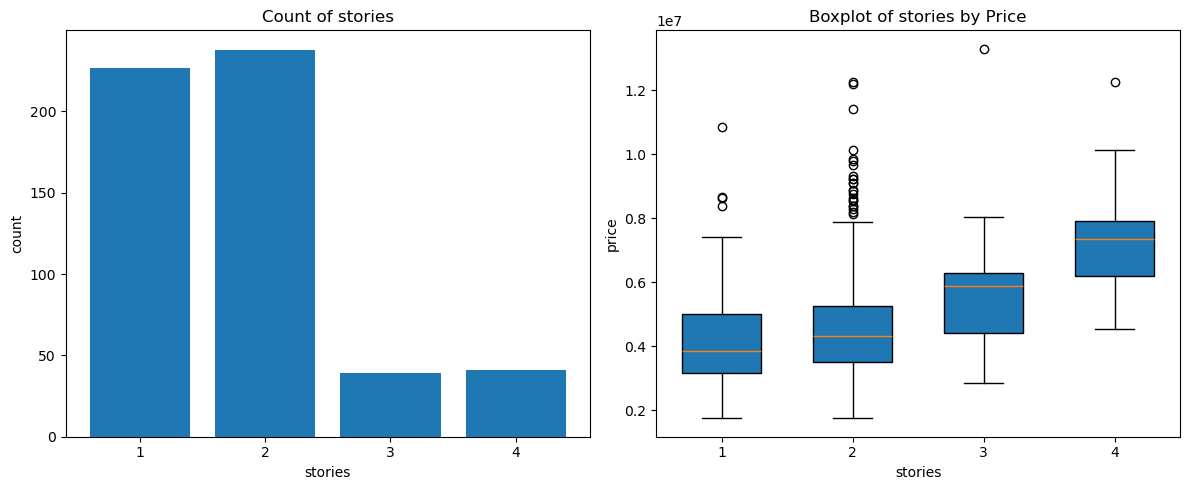

In [147]:
plt.figure(figsize=(12,5))

# 🔹 Biểu đồ 1: Count of stories
plt.subplot(1, 2, 1)

storie_count = data["stories"].value_counts().sort_index()

plt.bar(storie_count.index, storie_count.values)
plt.xticks(storie_count.index)
plt.title("Count of stories")
plt.xlabel("stories")
plt.ylabel("count")

# 🔹 Biểu đồ 2: Boxplot stories theo price
plt.subplot(1,2,2)
labels = sorted(data["stories"].unique())
groups = [data[data["stories"]==b]["price"] for b in labels]

plt.boxplot(groups, patch_artist=True, widths=0.6)
plt.title("Boxplot of stories by Price")
plt.xlabel("stories")
plt.ylabel("price")
plt.xticks(range(1,len(labels)+1), labels)

plt.tight_layout()
plt.show()

Biến "parking"

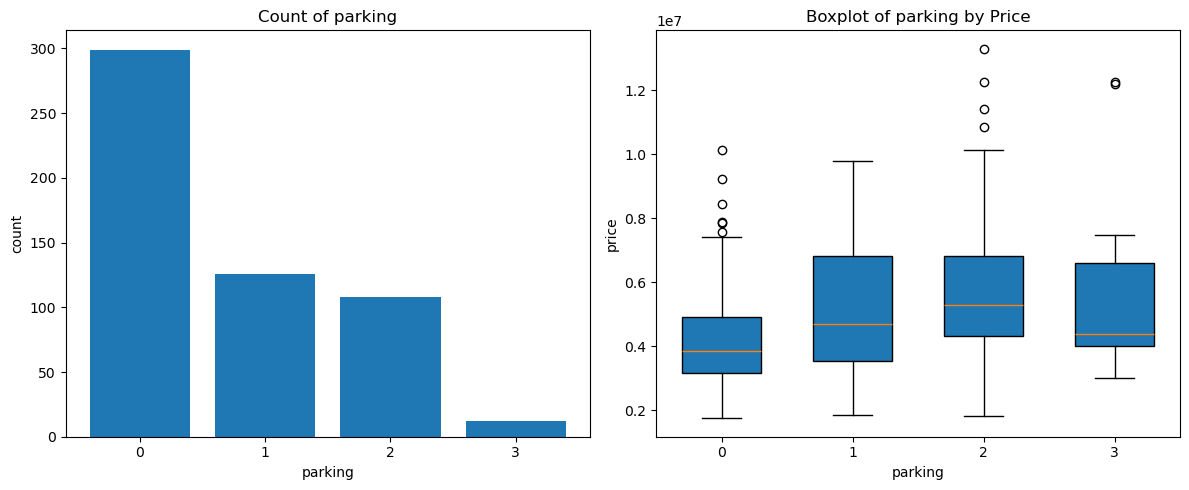

In [148]:
plt.figure(figsize=(12,5))

# 🔹 Biểu đồ 1: Count of parking
plt.subplot(1, 2, 1)

parking_count = data["parking"].value_counts().sort_index()

plt.bar(parking_count.index, parking_count.values)
plt.xticks(parking_count.index)
plt.title("Count of parking")
plt.xlabel("parking")
plt.ylabel("count")

# 🔹 Biểu đồ 2: Boxplot parking theo price
plt.subplot(1,2,2)
labels = sorted(data["parking"].unique())
groups = [data[data["parking"]==b]["price"] for b in labels]

plt.boxplot(groups, patch_artist=True, widths=0.6)
plt.title("Boxplot of parking by Price")
plt.xlabel("parking")
plt.ylabel("price")
plt.xticks(range(1,len(labels)+1), labels)

plt.tight_layout()
plt.show()

Biến "mainroad"

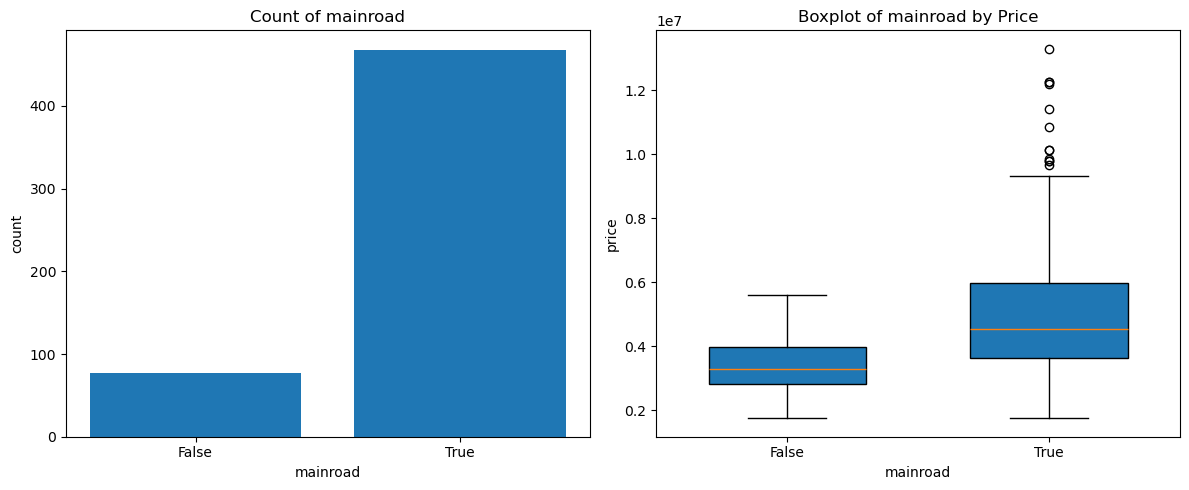

In [149]:
plt.figure(figsize=(12,5))

# 🔹 Biểu đồ 1: Count of mainroad
plt.subplot(1, 2, 1)

mainroad_count = data["mainroad"].value_counts().sort_index()

plt.bar(mainroad_count.index, mainroad_count.values)
plt.xticks(mainroad_count.index, ["False", "True"])
plt.title("Count of mainroad")
plt.xlabel("mainroad")
plt.ylabel("count")

# 🔹 Biểu đồ 2: Boxplot mainroad theo price
plt.subplot(1,2,2)
labels = sorted(data["mainroad"].unique())
groups = [data[data["mainroad"]==b]["price"] for b in labels]

plt.boxplot(groups, patch_artist=True, widths=0.6)
plt.title("Boxplot of mainroad by Price")
plt.xlabel("mainroad")
plt.ylabel("price")
plt.xticks(range(1,len(labels)+1), ["False", "True"])

plt.tight_layout()
plt.show()

Biến "guestroom"

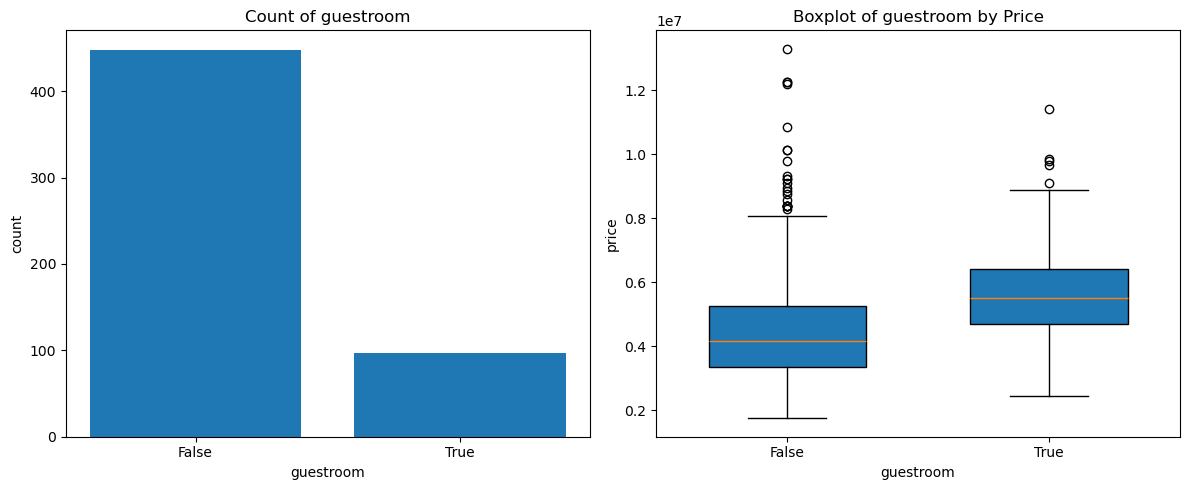

In [150]:
plt.figure(figsize=(12,5))

# 🔹 Biểu đồ 1: Count of guestroom
plt.subplot(1, 2, 1)

guestroom_count = data["guestroom"].value_counts().sort_index()

plt.bar(guestroom_count.index, guestroom_count.values)
plt.xticks(guestroom_count.index, ["False", "True"])
plt.title("Count of guestroom")
plt.xlabel("guestroom")
plt.ylabel("count")

# 🔹 Biểu đồ 2: Boxplot guestroom theo price
plt.subplot(1,2,2)
labels = sorted(data["guestroom"].unique())
groups = [data[data["guestroom"]==b]["price"] for b in labels]

plt.boxplot(groups, patch_artist=True, widths=0.6)
plt.title("Boxplot of guestroom by Price")
plt.xlabel("guestroom")
plt.ylabel("price")
plt.xticks(range(1,len(labels)+1), ["False", "True"])

plt.tight_layout()
plt.show()

Biến "basement"

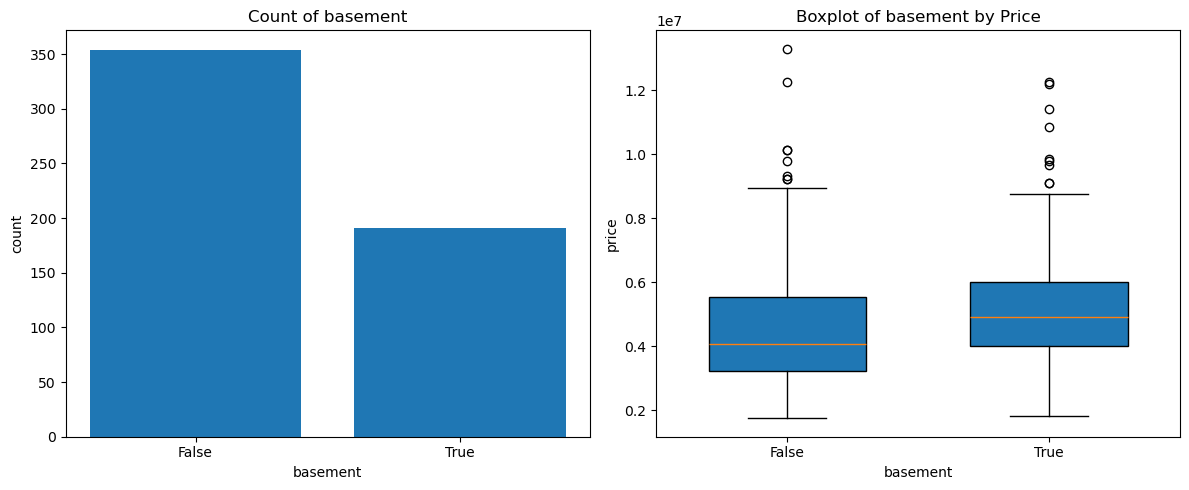

In [151]:
plt.figure(figsize=(12,5))

# 🔹 Biểu đồ 1: Count of basement
plt.subplot(1, 2, 1)

basement_count = data["basement"].value_counts().sort_index()

plt.bar(basement_count.index, basement_count.values)
plt.xticks(basement_count.index, ["False", "True"])
plt.title("Count of basement")
plt.xlabel("basement")
plt.ylabel("count")

# 🔹 Biểu đồ 2: Boxplot basement theo price
plt.subplot(1,2,2)
labels = sorted(data["basement"].unique())
groups = [data[data["basement"]==b]["price"] for b in labels]

plt.boxplot(groups, patch_artist=True, widths=0.6)
plt.title("Boxplot of basement by Price")
plt.xlabel("basement")
plt.ylabel("price")
plt.xticks(range(1,len(labels)+1), ["False", "True"])

plt.tight_layout()
plt.show()

Biến "hotwaterheating"

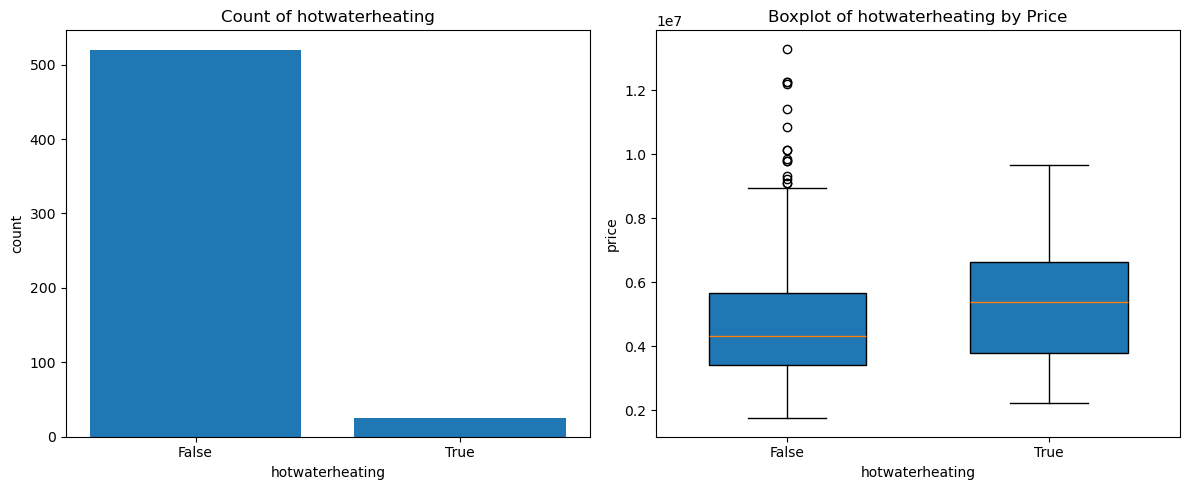

In [152]:
plt.figure(figsize=(12,5))

# 🔹 Biểu đồ 1: Count of hotwaterheating
plt.subplot(1, 2, 1)

hotwaterheating_count = data["hotwaterheating"].value_counts().sort_index()

plt.bar(hotwaterheating_count.index, hotwaterheating_count.values)
plt.xticks(hotwaterheating_count.index, ["False", "True"])
plt.title("Count of hotwaterheating")
plt.xlabel("hotwaterheating")
plt.ylabel("count")

# 🔹 Biểu đồ 2: Boxplot hotwaterheating theo price
plt.subplot(1,2,2)
labels = sorted(data["hotwaterheating"].unique())
groups = [data[data["hotwaterheating"]==b]["price"] for b in labels]

plt.boxplot(groups, patch_artist=True, widths=0.6)
plt.title("Boxplot of hotwaterheating by Price")
plt.xlabel("hotwaterheating")
plt.ylabel("price")
plt.xticks(range(1,len(labels)+1), ["False", "True"])

plt.tight_layout()
plt.show()

Biến "airconditioning"

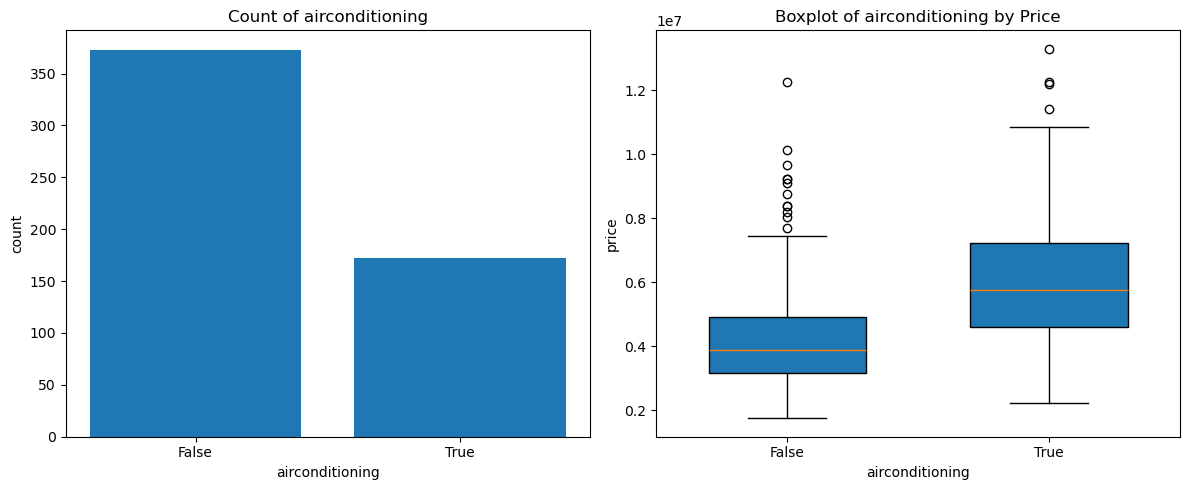

In [153]:
plt.figure(figsize=(12,5))

# 🔹 Biểu đồ 1: Count of airconditioning
plt.subplot(1, 2, 1)

airconditioning_count = data["airconditioning"].value_counts().sort_index()

plt.bar(airconditioning_count.index, airconditioning_count.values)
plt.xticks(airconditioning_count.index, ["False", "True"])
plt.title("Count of airconditioning")
plt.xlabel("airconditioning")
plt.ylabel("count")

# 🔹 Biểu đồ 2: Boxplot airconditioning theo price
plt.subplot(1,2,2)
labels = sorted(data["airconditioning"].unique())
groups = [data[data["airconditioning"]==b]["price"] for b in labels]

plt.boxplot(groups, patch_artist=True, widths=0.6)
plt.title("Boxplot of airconditioning by Price")
plt.xlabel("airconditioning")
plt.ylabel("price")
plt.xticks(range(1,len(labels)+1), ["False", "True"])

plt.tight_layout()
plt.show()

Biến "prefarea"

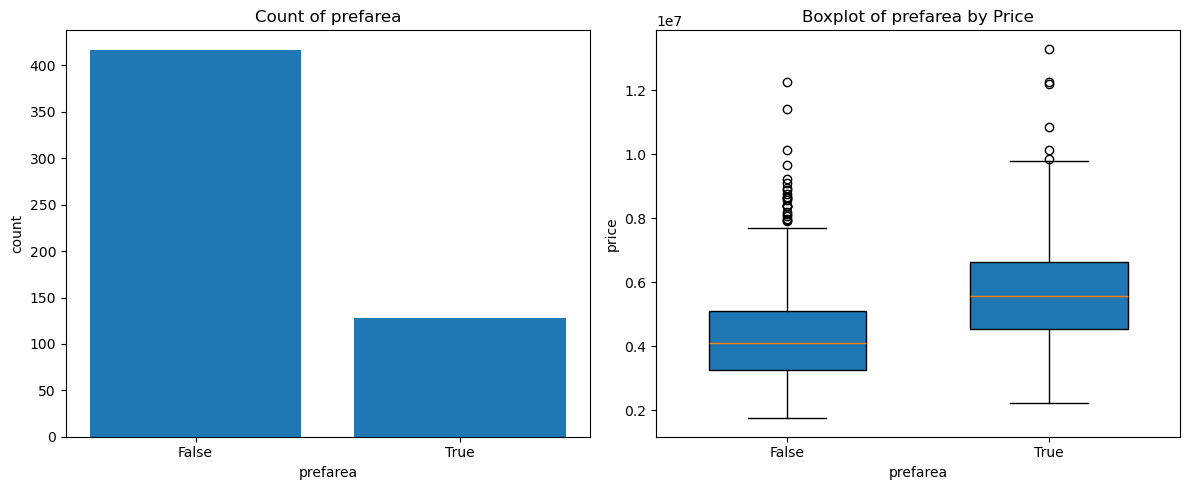

In [154]:
plt.figure(figsize=(12,5))

# 🔹 Biểu đồ 1: Count of prefarea
plt.subplot(1, 2, 1)

prefarea_count = data["prefarea"].value_counts().sort_index()

plt.bar(prefarea_count.index, prefarea_count.values)
plt.xticks(prefarea_count.index, ["False", "True"])
plt.title("Count of prefarea")
plt.xlabel("prefarea")
plt.ylabel("count")

# 🔹 Biểu đồ 2: Boxplot prefarea theo price
plt.subplot(1,2,2)
labels = sorted(data["prefarea"].unique())
groups = [data[data["prefarea"]==b]["price"] for b in labels]

plt.boxplot(groups, patch_artist=True, widths=0.6)
plt.title("Boxplot of prefarea by Price")
plt.xlabel("prefarea")
plt.ylabel("price")
plt.xticks(range(1,len(labels)+1), ["False", "True"])

plt.tight_layout()
plt.show()

Biến "furnishingstatus_semi-furnished"

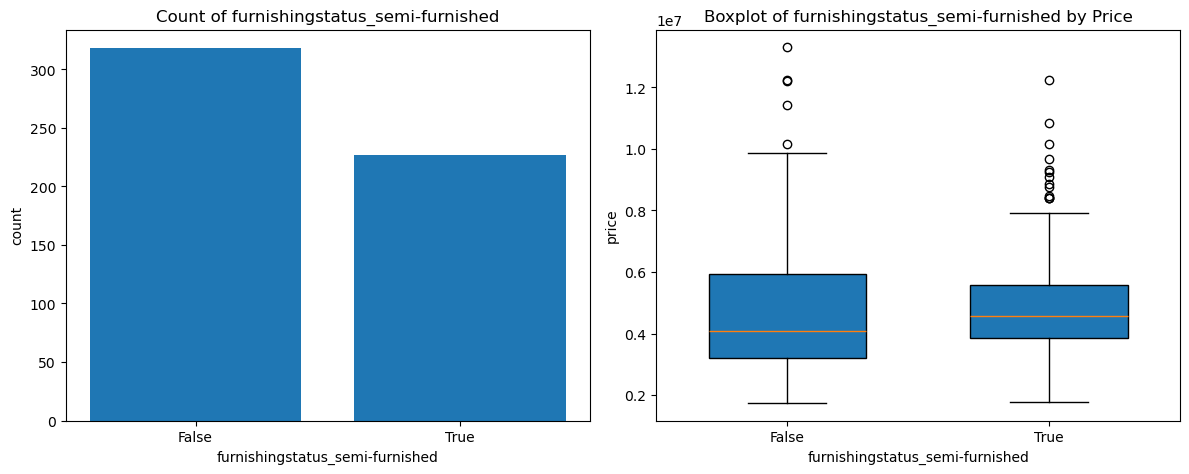

In [155]:
plt.figure(figsize=(12,5))

# 🔹 Biểu đồ 1: Count of furnishingstatus_semi-furnished
plt.subplot(1, 2, 1)

fur_count = data["furnishingstatus_semi-furnished"].value_counts().sort_index()

plt.bar(fur_count.index, fur_count.values)
plt.xticks(fur_count.index, ["False", "True"])
plt.title("Count of furnishingstatus_semi-furnished")
plt.xlabel("furnishingstatus_semi-furnished")
plt.ylabel("count")

# 🔹 Biểu đồ 2: Boxplot fur theo price
plt.subplot(1,2,2)
labels = sorted(data["furnishingstatus_semi-furnished"].unique())
groups = [data[data["furnishingstatus_semi-furnished"]==b]["price"] for b in labels]

plt.boxplot(groups, patch_artist=True, widths=0.6)
plt.title("Boxplot of furnishingstatus_semi-furnished by Price")
plt.xlabel("furnishingstatus_semi-furnished")
plt.ylabel("price")
plt.xticks(range(1,len(labels)+1), ["False", "True"])

plt.tight_layout()
plt.show()

Biến "furnishingstatus_unfurnished"

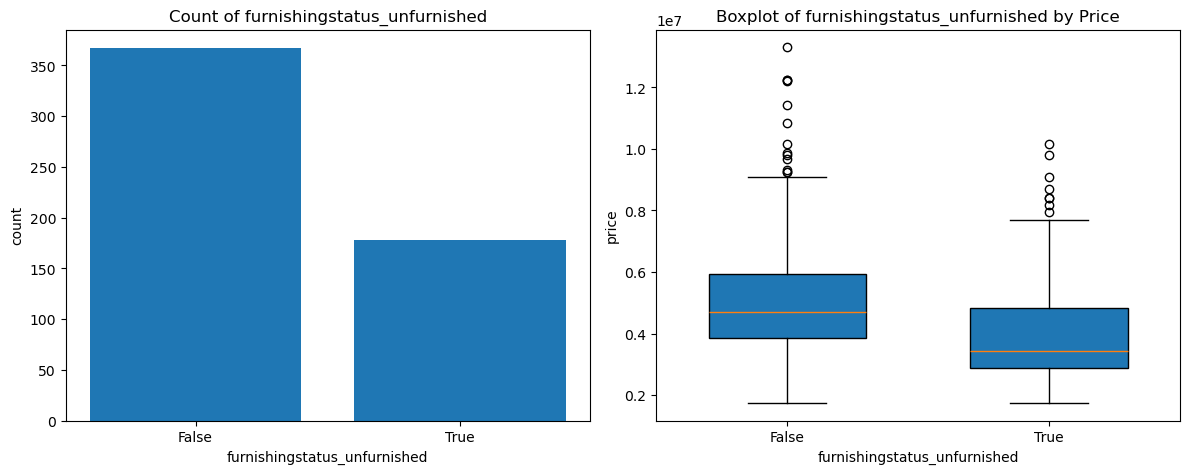

In [156]:
plt.figure(figsize=(12,5))

# 🔹 Biểu đồ 1: Count of fur
plt.subplot(1, 2, 1)

unfur = data["furnishingstatus_unfurnished"].value_counts().sort_index()

plt.bar(unfur.index, unfur.values)
plt.xticks(unfur.index, ["False", "True"])
plt.title("Count of furnishingstatus_unfurnished")
plt.xlabel("furnishingstatus_unfurnished")
plt.ylabel("count")

# 🔹 Biểu đồ 2: Boxplot fur theo price
plt.subplot(1,2,2)
labels = sorted(data["furnishingstatus_unfurnished"].unique())
groups = [data[data["furnishingstatus_unfurnished"]==b]["price"] for b in labels]

plt.boxplot(groups, patch_artist=True, widths=0.6)
plt.title("Boxplot of furnishingstatus_unfurnished by Price")
plt.xlabel("furnishingstatus_unfurnished")
plt.ylabel("price")
plt.xticks(range(1,len(labels)+1), ["False", "True"])

plt.tight_layout()
plt.show()